# Анализ лояльности пользователей Яндекс Афиши
- Автор: Багиров Фарид

# Содержание
<a id="содержание"></a>


### 0.1 [Цели и задачи проекта](#Цели-и-задачи-проекта)
### 0.2 [Описание данных](#Описание-данных)

## 1. [Загрузка данных](#Загрузка-данных)
### 1.1 [Подключение к базе данных](#Подключение-к-базе-данных)
### 1.2 [Выгрузка данных](#Выгрузка-данных)
### 1.3 [Первичная проверка](#Первичная-проверка)

## 2. [Предобработка данных](#Предобработка-данных)
### 2.1 [Приведение выручку к единой валюте — российскому рублю](#Приведение-выручку-к-единой-валюте-—-российскому-рублю)
### 2.2 [Преобразование типов данных](#Преобразование-типов-данных)
## 3. [Создание профиля пользователя](#Создание-профиля-пользователя)
### 3.1 [Построение профиля](#Построение-профиля) 
### 3.2 [Изучение значений профиля пользователей](#Изучение-значений-профиля-пользователей)
## 4. [Исследовательский анализ данных](#Исследовательский-анализ-данных)
### 4.1 [Исследование признаков первого заказа и их связи с возвращением на платформу](#Исследование-признаков-первого-заказа-и-их-связи-с-возвращением-на-платформу)
#### 4.1.1 [Изучение распределение пользователей по признакам.](#Изучение-распределение-пользователей-по-признакам.)
#### 4.1.2 [Анализ возвратов пользователей](#Анализ-возвратов-пользователей)
#### 4.1.3 [Проверка продуктовых гипотез](#Проверка-продуктовых-гипотез)
### 4.2 [Исследование поведения пользователей через показатели выручки и состава заказа](#Исследование-поведения-пользователей-через-показатели-выручки-и-состава-заказа)
#### 4.2.1 [Связь между средней выручкой сервиса с заказа и повторными заказами](#Связь-между-средней-выручкой-сервиса-с-заказа-и-повторными-заказами)
#### 4.2.2 [Распределение по средней выручке с заказа в двух группах пользователей](#Распределение-по-средней-выручке-с-заказа-в-двух-группах-пользователей)
#### 4.2.3 [Анализ влияние среднего количества билетов в заказе на вероятность повторной покупки](#Анализ-влияние-среднего-количества-билетов-в-заказе-на-вероятность-повторной-покупки)
### 4.3 [Исследование временных характеристик первого заказа и их влияния на повторные покупки](#Исследование-временных-характеристик-первого-заказа-и-их-влияния-на-повторные-покупки)
#### 4.3.1 [Как день недели, в которой была совершена первая покупка, влияет на поведение пользователей](#Как-день-недели,-в-которой-была-совершена-первая-покупка,-влияет-на-поведение-пользователей)
#### 4.3.2 [Как средний интервал между заказами влияет на удержание клиентов](#Как-средний-интервал-между-заказами-влияет-на-удержание-клиентов)
### 4.4 [Корреляционный анализ количества покупок и признаков пользователя](#Корреляционный-анализ-количества-покупок-и-признаков-пользователя)
#### 4.4.1 [Корреляционный анализ](#Корреляционный-анализ)
## 5. [Общие выводы и рекомендации](#Общие-выводы-и-рекомендации)

## Введение

### Цели и задачи проекта

Команда маркетинга хочет лучше понимать поведение пользователей. Для этого они просят вас провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
Оптимизировать маркетинговые бюджеты.
Повысить общий уровень удержания клиентов.

### Описание данных 

- user_id — уникальный идентификатор пользователя, совершившего заказ;
- device_type_canonical — тип устройства, с которого был оформлен заказ ( mobile — мобильные устройства, desktop — стационарные);
- order_id — уникальный идентификатор заказа;
- order_dt — дата создания заказа (используйте данные created_dt_msk );
- order_ts — дата и время создания заказа (используйте данные created_ts_msk );
- currency_code — валюта оплаты;
- revenue — выручка от заказа;
- tickets_count — количество купленных билетов;
- days_since_prev — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- event_id — уникальный идентификатор мероприятия;
- service_name — название билетного оператора;
- event_type_main — основной тип мероприятия (театральная постановка, концерт и так далее);
- region_name — название региона, в котором прошло мероприятие;
- city_name — название города, в котором прошло мероприятие.

# Загрузка данных

### Подключение к базе данных

In [1]:
!pip install sqlalchemy

In [2]:
!pip install psycopg2

In [3]:
!pip install phik

In [2]:
!pip install python-dotenv

In [13]:
#импорт необходимых для проекта библеотек
from sqlalchemy import create_engine
from phik import phik_matrix
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [14]:
load_dotenv()

False

In [18]:
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

In [19]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [20]:
engine = create_engine(connection_string)

ValueError: invalid literal for int() with base 10: 'None'

### Выгрузка данных

In [8]:
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk,
    p.created_ts_msk,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (created_dt_msk::date - LAG(created_dt_msk) OVER(PARTITION BY user_id ORDER BY created_dt_msk)::date) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    c.city_name,
    r.region_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id 
LEFT JOIN afisha.regions r ON c.region_id = r.region_id  
WHERE (P.device_type_canonical = 'mobile' OR p.device_type_canonical = 'desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id;
'''

In [9]:
df = pd.read_sql_query(query, con=engine)

### Первичная проверка

In [10]:
#информация о полученном датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [11]:
#проверка данных
df.head()


,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,city_name,region_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Глиногорск,Каменевский регион
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Глиногорск,Каменевский регион
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Глиногорск,Каменевский регион
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Озёрск,Североярская область
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Родниковецк,Озернинский край


Данные выгружены корректно: 290 611 строк и 15 столбцов. Типы данных в целом соответствуют ожидаемым: даты в datetime, числовые поля — в int/float, текстовые поля — в object.
Пропуски присутствуют только в поле days_since_prev для первой покупки пользователя — это логично.
На этапе предобработки потребуется проверить отрицательные и аномальные значения в поле revenue, возможно переименовать и структурировать колонки для удобства анализа.

[← Вернуться к содержанию](#содержание)

## Предобработка данных

### Приведение выручку к единой валюте — российскому рублю

In [12]:
#загрузка данных о курсе тенге
tenge_df = pd.read_csv('final_tickets_tenge_df.csv')

In [13]:
#проверка данных 
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [14]:
#для успешного объединения меняю тип данных в поле data
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

In [15]:
tenge_df = tenge_df.rename(columns={'data': 'created_dt_msk'})

In [16]:
#объединяю таблицы для дальнейших расчётов
df = df.merge(tenge_df[['created_dt_msk', 'curs']], on='created_dt_msk', how='left')

In [17]:
#функция для перевода в рубли
def change_curr(row):
    if row['currency_code'] == 'kzt':
        return round(row['revenue'] * row['curs'] / 100, 2)
    else:
        return row['revenue']

In [18]:
#сохранение результата в новый столбец revenue_rub
df['revenue_rub'] = df.apply(change_curr, axis=1)

In [19]:
#убираю лишнее поле curs
df = df.drop(columns=['curs'])

In [20]:
#проверка
df.head()

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,city_name,region_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Глиногорск,Каменевский регион,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Глиногорск,Каменевский регион,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Глиногорск,Каменевский регион,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Озёрск,Североярская область,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Родниковецк,Озернинский край,1390.41


### Преобразование типов данных 

In [21]:
#создаю копию датафрейма для дальнейшей работы 
df_work = df.copy()

In [22]:
#оптимизация типов данных
df_work = df_work.astype({
    "tickets_count": "int8",
    "revenue": "float32",
    "currency_code": "category",
    "days_since_prev": "Int16"
})

In [23]:
#изучение ключевых столбцов tickets_count, revenue_rub и days_since_prev 
df_work['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

In [24]:
df_work['revenue_rub'].describe()

count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

In [25]:
df_work['days_since_prev'].describe()

count    268678.000000
mean          3.222381
std          11.350509
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

In [26]:
#считаю количство строк с отрицательным значением в выручке 
neg_revenue = df_work[df_work['revenue_rub'] < 0].shape[0]
print(f"Строк с отрицательной выручкой: {neg_revenue}")

#провожу фильтрацию
df_work = df_work[df_work['revenue_rub'] >= 0]

#проверяю размерность после фильтрации
print(f"Осталось строк: {df_work.shape[0]}")

Строк с отрицательной выручкой: 381
Осталось строк: 290230


In [27]:
#проверка уникальных значений
df_work['currency_code'].unique()

['rub', 'kzt']
Categories (2, object): ['kzt', 'rub']

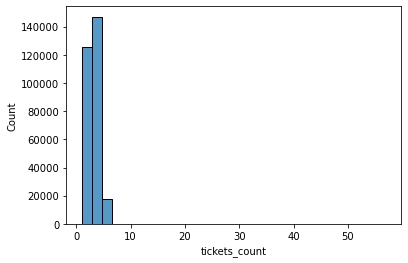

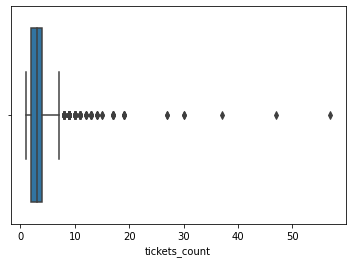

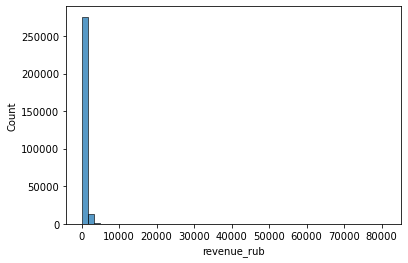

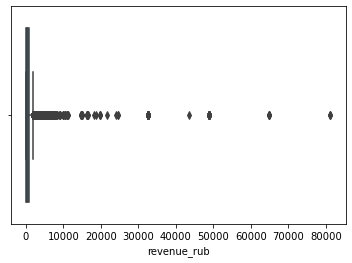

In [28]:
#проверка численных данных и наличие в них выбросов

#гистограмма и boxplot для tickets_count 
sns.histplot(df_work['tickets_count'], bins=30)
plt.show()
sns.boxplot(x=df_work['tickets_count'])
plt.show()

#гистограмма и boxplot для revenue_rub
sns.histplot(df_work['revenue_rub'], bins=50)
plt.show()
sns.boxplot(x=df_work['revenue_rub'])
plt.show()

In [29]:
#количетсво строк до фильтрации 
total_rows = df_work.shape[0]

#находим 99-й перцентиль
perc99 = df_work['revenue_rub'].quantile(0.99)

#фильтруем
df_work = df_work[df_work['revenue_rub'] <= perc99]

In [30]:
#сколько строк осталось после фильтрации
df_work.shape[0]

287405

1. Был создан новый столбец revenue_rub, для отображения выручки в рублях
2. Ключевые столбцы tickets_count, revenue_rub, days_since_prev проверены на ошибки и выбросы
3. Строки с отрицательной выручкой удалены, далее распределение выручки проверено и обрезано по 99-му перцентилю
4. Столбец currency_code нормализован и приведён к типу category
5. Столбец tickets_count приведён к типу int8, days_since_prev — к Int16 (nullable), revenue_rub — к float32
6. После фильтрации и очистки данных осталось 287405 строк (исходного набора в 290611)
7. Данные готовы для дальнейшего анализа и визуализации

[← Вернуться к содержанию](#содержание)

## Создание профиля пользователя

### Построение профиля

In [31]:
#сортировка по дате совершения заказа
df_work = df_work.sort_values(by=['user_id', 'created_dt_msk'])

In [32]:
#первый и последний заказ пользователя
user_profile = df_work.groupby('user_id').agg(
    first_order_date=('created_dt_msk', 'first'),
    last_order_date=('created_dt_msk', 'last')
)

In [33]:
df_work.columns

Index(['user_id', 'device_type_canonical', 'order_id', 'created_dt_msk',
       'created_ts_msk', 'currency_code', 'revenue', 'tickets_count',
       'days_since_prev', 'event_id', 'event_name', 'event_type_main',
       'service_name', 'city_name', 'region_name', 'revenue_rub'],
      dtype='object')

In [34]:
#информация о первом заказе пользователя 
first_order_info = df_work.groupby('user_id').first()[['device_type_canonical', 
                                                       'region_name', 
                                                       'service_name', 
                                                       'event_type_main']]

In [35]:
#объединяю с профилем информацию о заказе
user_profile = user_profile.join(first_order_info)

In [36]:
#статистика заказов
stats = df_work.groupby('user_id').agg(
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between_orders=('days_since_prev', 'mean')
)
#объединяю с профилем 
user_profile = user_profile.join(stats)

In [37]:
#добавление бинарных признаков
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

### Изучение значений профиля пользователей

In [38]:
#общее число пользователей в выборке
user_profile.shape[0]

21838

In [39]:
#средняя выручка с оного заказа
mean_revenue_order = user_profile['avg_revenue'].mean()
print(f'средняя выручка с одного заказа: {mean_revenue_order:.2f} руб.')  

средняя выручка с одного заказа: 545.03 руб.


In [40]:
#доля пользователей с двумя и более заказами
share_two_order = user_profile['is_two'].mean()
print(f'доля пользователей с двумя и более заказами: {share_two_order:.2%}')

доля пользователей с двумя и более заказами: 61.70%


In [41]:
#доля пользователей с пятью и более заказами
share_two_order = user_profile['is_five'].mean()
print(f'доля пользователей с двумя и более заказами: {share_two_order:.2%}')

доля пользователей с двумя и более заказами: 29.00%


In [42]:
#статистические показатели
user_profile[['total_orders', 'avg_tickets', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets,avg_days_between_orders
count,21838.000000,21838.000000,13511.000000
mean,13.160775,2.744062,15.847068
std,121.577370,0.913083,22.304516
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.414286
max,10168.000000,11.000000,148.000000


1. total_orders
* Большинство пользователей совершают 1–5 заказов.
* Есть редкие активные пользователи с очень большим числом заказов (до 10 тыс.) — это потенциальные выбросы, либо корпоративные аккаунты.
* Стандартное отклонение очень большое (121.57) - указывает на сильную асимметрию распределения.
2. avg_tickets
* В большинстве заказов 2–3 билета, что логично для обычных пользователей.
* Максимальные значения (до 11 билетов) — редкие, но ещё в пределах разумного.
* Стандартное отклонение небольшое (0.91), выбросов почти нет.
3. avg_days_between_orders
* Большинство пользователей покупают с интервалом несколько дней до 3 недель.
* NaN для пользователей с одним заказом - 13 511 пользователей (из 21 838)
* Максимальные значения (148 дней) - редкие пользователи, долгие интервалы.

In [43]:
#нахожу 99 процентиль
perc99_orders = user_profile['total_orders'].quantile(0.99)

#фильтрация пользователей
user_profile_work = user_profile[user_profile['total_orders'] <= perc99_orders]

#размер данных после фильтрации
user_profile_work.shape[0]

#После фильтрации остаётся 99% пользователей, экстремальные выбросы удалены
#Средние и медианные показатели становятся более репрезентативными
#Выбросы оставляют значимый процент данных нетронутым, поэтому анализ не искажен

21622

In [44]:
user_profile_work[['total_orders', 'avg_tickets', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets,avg_days_between_orders
count,21622.000000,21622.000000,13295.000000
mean,6.496624,2.744256,16.097071
std,14.310784,0.917491,22.397847
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.333333
50%,2.000000,2.750000,8.375000
75%,5.000000,3.100000,20.750000
max,152.000000,11.000000,148.000000


1. Создан профиль пользователя с ключевыми характеристиками (первые и последние заказы, устройство, регион, партнёр, жанр события, количество заказов, средняя выручка, среднее количество билетов, среднее время между заказами).

2. Добавлены два бинарных признака: is_two (2 и более заказов) и is_five (5 и более заказов).

3. Проведены расчёты для первичного анализа активности пользователей и выявления репрезентативности данных.

4. Аномалии по числу заказов отфильтрованы (выше 99-го перцентиля), данные готовы для дальнейшего анализа.

[← Вернуться к содержанию](#содержание)

## Исследовательский анализ данных

### Исследование признаков первого заказа и их связи с возвращением на платформу



####  Изучение распределение пользователей по признакам

In [45]:
#подсчет количества и доли по типу первого мероприятия
total_event_type = user_profile_work.groupby('event_type_main').size()

df_event = total_event_type.reset_index(name='users_count')
df_event['share'] = df_event['users_count'] / df_event['users_count'].sum()
df_event.sort_values(by='users_count', ascending=False)

,event_type_main,users_count,share
2,концерты,9565,0.442374
1,другое,5407,0.250069
5,театр,4230,0.195634
4,стендап,1111,0.051383
3,спорт,799,0.036953
0,выставки,415,0.019193
6,ёлки,95,0.004394


In [46]:
#подсчет количества и доли по типу устройства
total_device_type = user_profile_work.groupby('device_type_canonical').size()

df_device = total_device_type.reset_index(name='users_count')
df_device['share'] = df_device['users_count'] / df_device['users_count'].sum()
df_device.sort_values(by='users_count', ascending=False)

,device_type_canonical,users_count,share
1,mobile,17883,0.827074
0,desktop,3739,0.172926


In [47]:
#подсчет количества и доли по региону
total_region = user_profile_work.groupby('region_name').size()

df_region = total_region.reset_index(name='users_count')
df_region['share'] = df_region['users_count'] / df_region['users_count'].sum()
df_region.sort_values(by='users_count', ascending=False)

,region_name,users_count,share
23,Каменевский регион,7089,0.327861
60,Североярская область,3766,0.174174
77,Широковская область,1221,0.056470
45,Озернинский край,677,0.031311
41,Малиновоярский округ,527,0.024373
...,...,...,...
17,Залесский край,2,0.000092
70,Тихогорская область,2,0.000092
5,Верхозёрский край,1,0.000046
66,Сосноводолинская область,1,0.000046


In [48]:
#подсчет количества и доли по билетному оператору
total_service_name = user_profile_work.groupby('service_name').size()

df_service = total_service_name.reset_index(name='users_count')
df_service['share'] = df_service['users_count'] / df_service['users_count'].sum()
df_service.sort_values(by='users_count', ascending=False)

,service_name,users_count,share
3,Билеты без проблем,5153,0.238322
22,Мой билет,2974,0.137545
19,Лови билет!,2808,0.129868
4,Билеты в руки,2562,0.118490
23,Облачко,2179,0.100777
7,Весь в билетах,1279,0.059153
20,Лучшие билеты,1189,0.054990
24,Прачечная,581,0.026871
17,Край билетов,454,0.020997
12,Дом культуры,356,0.016465


Распределение пользователей по сегментам неравномерное.

По типу первого мероприятия:
Наиболее популярный сегмент — концерты (9 565 пользователей, 44 %), тогда как наименее популярные типы («ёлки», «выставки») составляют менее 1 % от всех пользователей.
→ Здесь явно видна «точка входа» — концертные мероприятия.

По типу устройства:
Большинство пользователей совершают первый заказ с мобильных устройств (82,7 %), десктоп — лишь 17,3 %.
→ Явная доминирующая точка входа — мобильные пользователи.

По региону:
Лидирующие регионы: Каменевский регион (32,8 %) и Североярская область (17,4 %).
→ Есть явные регионы с высокой концентрацией пользователей, а мелкие регионы имеют минимальное количество пользователей.

По билетному оператору:
Наибольшее количество пользователей оформляли первый заказ через «Билеты без проблем» (23,8 %), затем «Мой билет» и «Лови билет!».
→ Наблюдается концентрация пользователей на нескольких популярных операторах, остальные операторы крайне редкие.

#### Анализ возвратов пользователей

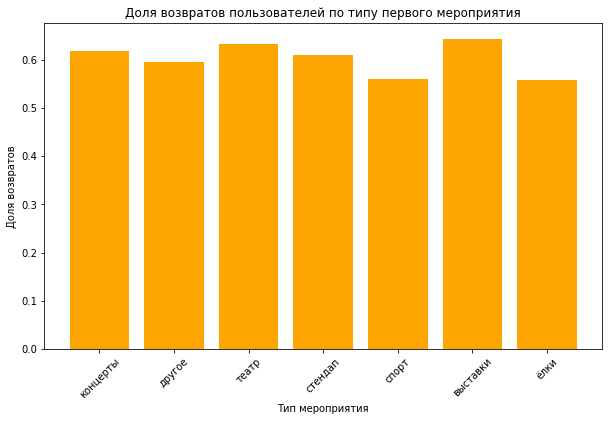

In [49]:
#доля пользователей, совершивших два и более заказа по типу мероприятия
returned_users = user_profile_work[user_profile_work['total_orders'] >= 2]
returned_count = returned_users.groupby('event_type_main').size().reset_index(name='returned_users')
total_count = user_profile_work.groupby('event_type_main').size().reset_index(name='users_count')
df_event_return = total_count.merge(returned_count, on='event_type_main', how='left')
df_event_return['return_rate'] = df_event_return['returned_users'] / df_event_return['users_count']
df_event_return['return_rate'] = df_event_return['return_rate'].fillna(0)
df_event_return = df_event_return.sort_values(by='users_count', ascending=False)

#визуализация
plt.figure(figsize=(10,6))
plt.bar(df_event_return['event_type_main'], df_event_return['return_rate'], color='orange')
plt.title('Доля возвратов пользователей по типу первого мероприятия')
plt.ylabel('Доля возвратов')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=45)
plt.show()

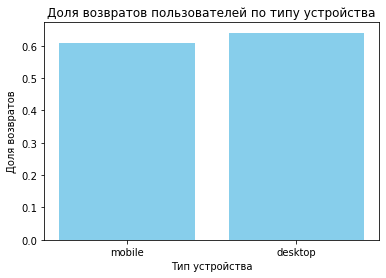

In [50]:
#доля пользователей, совершивших два и более заказа по типу устройства
returned_users = user_profile_work[user_profile_work['total_orders'] >= 2]
returned_device = returned_users.groupby('device_type_canonical').size().reset_index(name='returned_users')
total_device = user_profile_work.groupby('device_type_canonical').size().reset_index(name='users_count')
df_device_return = total_device.merge(returned_device, on='device_type_canonical', how='left')
df_device_return['return_rate'] = df_device_return['returned_users'] / df_device_return['users_count']
df_device_return['return_rate'] = df_device_return['return_rate'].fillna(0)
df_device_return.sort_values(by='users_count', ascending=False, inplace=True)

#визуализация 
plt.figure(figsize=(6,4))
plt.bar(df_device_return['device_type_canonical'], df_device_return['return_rate'], color='skyblue')
plt.title('Доля возвратов пользователей по типу устройства')
plt.ylabel('Доля возвратов')
plt.xlabel('Тип устройства')
plt.show()

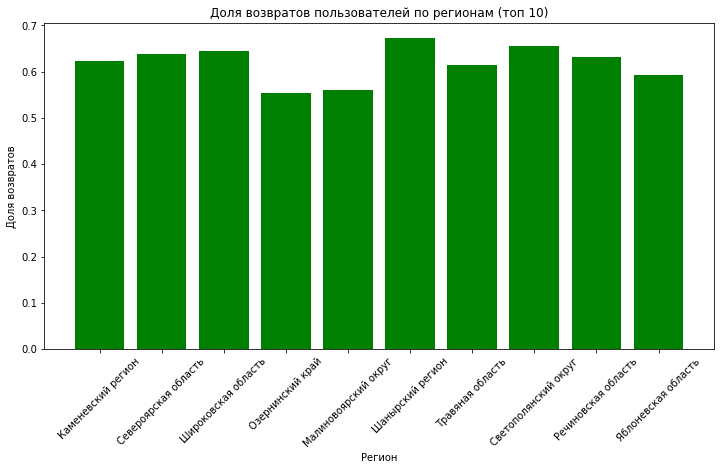

In [51]:
#доля пользователей, совершивших два и более заказа по региону
returned_region = returned_users.groupby('region_name').size().reset_index(name='returned_users')
total_region = user_profile_work.groupby('region_name').size().reset_index(name='users_count')
df_region_return = total_region.merge(returned_region, on='region_name', how='left')
df_region_return['return_rate'] = df_region_return['returned_users'] / df_region_return['users_count']
df_region_return['return_rate'] = df_region_return['return_rate'].fillna(0)

#топ-10 по числу пользователей для визуализации
df_region_return_top10 = df_region_return.sort_values(by='users_count', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(df_region_return_top10['region_name'], df_region_return_top10['return_rate'], color='green')
plt.title('Доля возвратов пользователей по регионам (топ 10)')
plt.ylabel('Доля возвратов')
plt.xlabel('Регион')
plt.xticks(rotation=45)
plt.show()

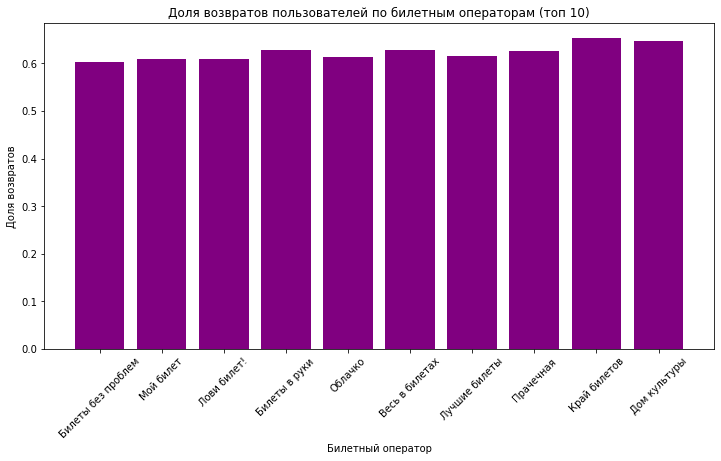

In [52]:
#доля пользователей, совершивших два и более заказа по билетному оператору
returned_service = returned_users.groupby('service_name').size().reset_index(name='returned_users')
total_service = user_profile_work.groupby('service_name').size().reset_index(name='users_count')
df_service_return = total_service.merge(returned_service, on='service_name', how='left')
df_service_return['return_rate'] = df_service_return['returned_users'] / df_service_return['users_count']
df_service_return['return_rate'] = df_service_return['return_rate'].fillna(0)

# Берём топ-10 по числу пользователей для визуализации
df_service_return_top10 = df_service_return.sort_values(by='users_count', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(df_service_return_top10['service_name'], df_service_return_top10['return_rate'], color='purple')
plt.title('Доля возвратов пользователей по билетным операторам (топ 10)')
plt.ylabel('Доля возвратов')
plt.xlabel('Билетный оператор')
plt.xticks(rotation=45)
plt.show()

Наибольшая доля возвратов наблюдается среди пользователей, купивших билеты на концерты и через мобильное устройство. При этом стоит учитывать, что сегменты с очень малым количеством пользователей (например, некоторые регионы или операторы с десятками клиентов) показывают нестабильные доли возвратов и могут не отражать общую тенденцию

#### Проверка продуктовых гипотез

__Гипотеза 1__. `Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.`

In [53]:
#сортируем по доле возвратов
df_event_return.sort_values(by='return_rate', ascending=False)

,event_type_main,users_count,returned_users,return_rate
0,выставки,415,267,0.643373
5,театр,4230,2678,0.633097
2,концерты,9565,5913,0.618191
4,стендап,1111,677,0.609361
1,другое,5407,3223,0.596079
3,спорт,799,448,0.560701
6,ёлки,95,53,0.557895


Гипотеза о том, что спортивные мероприятия стимулируют более частые возвраты на яндекс Афишу, не подтверждается.
- Пользователи, пришедшие на выставки и театр, возвращаются чаще всего (~64% и ~63%).
- Наименее высокая доля повторных заказов у спортивных мероприятий и ёлок (~56%).

__Гипотеза 2.__ `В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.`

In [54]:
#выбираем топ-10 регионов по числу пользователей
top_regions = df_region_return.sort_values(by='users_count', ascending=False).head(10)
top_regions.sort_values(by='return_rate', ascending=False)

,region_name,users_count,returned_users,return_rate
76,Шанырский регион,500,336.0,0.672000
57,Светополянский округ,456,299.0,0.655702
77,Широковская область,1221,786.0,0.643735
60,Североярская область,3766,2403.0,0.638078
52,Речиновская область,438,277.0,0.632420
23,Каменевский регион,7089,4424.0,0.624065
74,Травяная область,487,299.0,0.613963
78,Яблоневская область,411,244.0,0.593674
41,Малиновоярский округ,527,295.0,0.559772
45,Озернинский край,677,375.0,0.553914


- Самые посещаемые регионы не всегда имеют самую высокую долю повторных заказов. Например, Каменевский регион имеет много пользователей, но return_rate (доля вернувшихся пользователей ~62%) ниже, чем у менее крупных регионов (например, Шанырский — 67%).
- Итог: высокая численность пользователей в регионе не гарантирует более частых возвратов, есть «точки входа» с меньшим числом пользователей, где возврат выше.

### Исследование поведения пользователей через показатели выручки и состава заказа

#### Связь между средней выручкой сервиса с заказа и повторными заказами

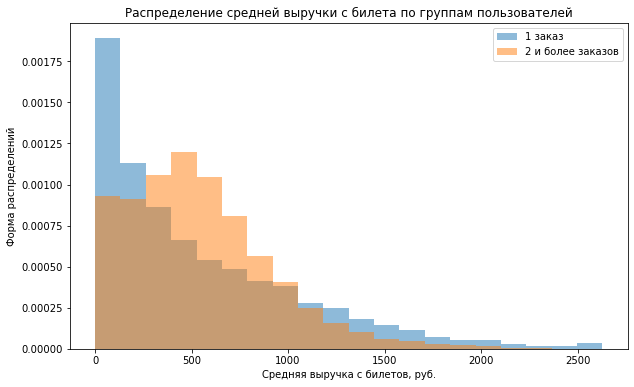

In [55]:
#две группы пользователей
one_orders = user_profile_work[user_profile_work['total_orders'] == 1]
many_orders = user_profile_work[user_profile_work['total_orders'] >= 2]

#количество интервалов и прозрачность
bins = 20  
alpha = 0.5

plt.figure(figsize=(10,6))

plt.hist(one_orders['avg_revenue'], bins=bins, alpha=alpha, density=True, label='1 заказ')
plt.hist(many_orders['avg_revenue'], bins=bins, alpha=alpha, density=True, label='2 и более заказов')

plt.xlabel('Средняя выручка с билетов, руб.')
plt.ylabel('Форма распределений')
plt.title('Распределение средней выручки с билета по группам пользователей')
plt.legend()
plt.show()

#### Распределение по средней выручке с заказа в двух группах пользователей

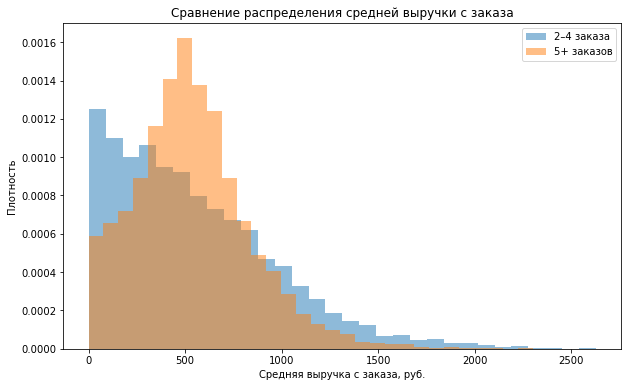

In [56]:
#группы пользователей совершившие 2-4 заказа и совершившие 5 и более 
group_2_4 = user_profile_work[user_profile_work['total_orders'].between(2, 4)]
group_5 = user_profile_work[user_profile_work['total_orders'] >= 5]

plt.figure(figsize=(10,6))

bins = 30 
alpha = 0.5

plt.hist(group_2_4['avg_revenue'], bins=bins, alpha=alpha, density=True, label='2–4 заказа')
plt.hist(group_5['avg_revenue'], bins=bins, alpha=alpha, density=True, label='5+ заказов')

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Сравнение распределения средней выручки с заказа')
plt.legend()
plt.show()

Да, различия есть. Пользователи, совершившие 5 и более заказов, имеют более равномерное распределение средней выручки с заказа с пиком около 500 руб., тогда как пользователи с 2–4 заказами сосредоточены в основном в низком диапазоне (с пиком до 500 руб.). Это говорит о том, что более активные пользователи тратят стабильно больше на каждый заказ по сравнению с менее активными.

#### Анализ влияние среднего количества билетов в заказе на вероятность повторной покупки

In [57]:
# Сегментация по среднему количеству билетов

#создаём словарь, чтобы хранить результаты
tickets_segments = {
    '1-2': user_profile_work[(user_profile_work['avg_tickets'] >= 1) & (user_profile_work['avg_tickets'] < 2)],
    '2-3': user_profile_work[(user_profile_work['avg_tickets'] >= 2) & (user_profile_work['avg_tickets'] < 3)],
    '3-5': user_profile_work[(user_profile_work['avg_tickets'] >= 3) & (user_profile_work['avg_tickets'] < 5)],
    '5+':  user_profile_work[user_profile_work['avg_tickets'] >= 5]
}
tickets_summary = []

# проходим по сегментам и считаем пользователей и вернувшихся
for seg, df in tickets_segments.items():
    users_count = len(df)
    returned_users = df['is_two'].sum() 
    return_rate = returned_users / users_count
    tickets_summary.append([seg, users_count, returned_users, return_rate])

# создаём DataFrame
tickets_summary_df = pd.DataFrame(tickets_summary, columns=['tickets_segment', 'users_count', 'returned_users', 'return_rate'])

tickets_summary_df

,tickets_segment,users_count,returned_users,return_rate
0,1-2,2410,1235,0.512448
1,2-3,9487,6979,0.735638
2,3-5,9064,4921,0.542917
3,5+,661,124,0.187595


__Распределение пользователей по сегментам:__
- Пользователи распределены неравномерно, концентрированы в средних сегментах: 2–3 билета (9487 пользователей) и 3–5 билетов (9064 пользователей).
- Сегменты 1–2 билета (2410 пользователей) и 5+ билетов (661 пользователь) значительно меньше по численности.

__Доля повторных покупок:__
- Аномально высокая доля повторных покупок у сегмента 2–3 билета — 73,6%.
- Аномально низкая доля повторных покупок у сегмента 5+ билетов — 18,8%.
- Остальные сегменты (1–2 билета и 3–5 билетов) имеют средние значения — около 51–54%.

Наиболее успешными по удержанию пользователей являются сегменты со средним количеством билетов в заказе (2–3), а слишком маленькие или очень большие заказы чаще не приводят к повторным покупкам.

### Исследование временных характеристик первого заказа и их влияния на повторные покупки

#### Как день недели, в которой была совершена первая покупка, влияет на поведение пользователей

In [58]:
#создаю копию и столбец с днём недели
user_profile_work = user_profile_work.copy()
user_profile_work['first_order_weekday'] = user_profile_work['first_order_date'].dt.day_name()

#подсчёт общего числа пользователей по каждому дню недели
weekday_summary = user_profile_work.groupby('first_order_weekday').agg(
    users_count = ('first_order_date', 'count'),  # считаем количество пользователей в дне
    returned_users = ('is_two', 'sum')            # суммируем тех, кто вернулся
)

# Доля вернувшихся
weekday_summary['return_rate'] = weekday_summary['returned_users'] / weekday_summary['users_count']


# Сортируем по дню недели для красоты (понедельник – воскресенье)
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_summary = weekday_summary.reindex(weekday_order)
weekday_summary

,users_count,returned_users,return_rate
first_order_weekday,,,
Monday,2918,1838,0.629883
Tuesday,3175,1965,0.618898
Wednesday,3061,1906,0.622672
Thursday,3112,1850,0.594473
Friday,3256,1946,0.597666
Saturday,3323,2086,0.627746
Sunday,2777,1668,0.600648


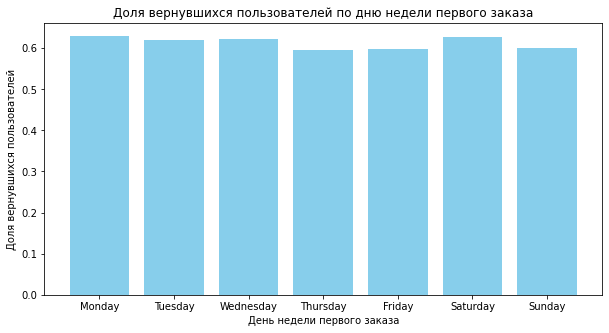

In [59]:
#визуализация 
plt.figure(figsize=(10,5))
plt.bar(weekday_summary.index, weekday_summary['return_rate'], color='skyblue')
plt.title('Доля вернувшихся пользователей по дню недели первого заказа')
plt.ylabel('Доля вернувшихся пользователей')
plt.xlabel('День недели первого заказа')
plt.show()

День недели первой покупки влияет на возврат очень слабо. Основная доля пользователей возвращается вне зависимости от того, в какой день они совершили первый заказ.

#### Как средний интервал между заказами влияет на удержание клиентов

In [60]:
#группы пользователей совершившие 2-4 заказа и совершившие 5 и более 
group_2_4 = user_profile_work[user_profile_work['total_orders'].between(2, 4)]
group_5 = user_profile_work[user_profile_work['total_orders'] >= 5]

mean_2_4 = group_2_4['avg_days_between_orders'].mean()
print('Средний интервал между заказами (2-4 заказа):', mean_2_4)

# Средний интервал для группы 5+ заказов
mean_5 = group_5['avg_days_between_orders'].mean()
print('Средний интервал между заказами (5+ заказов):', mean_5)

Средний интервал между заказами (2-4 заказа): 21.32867842643147
Средний интервал между заказами (5+ заказов): 9.906771519426506


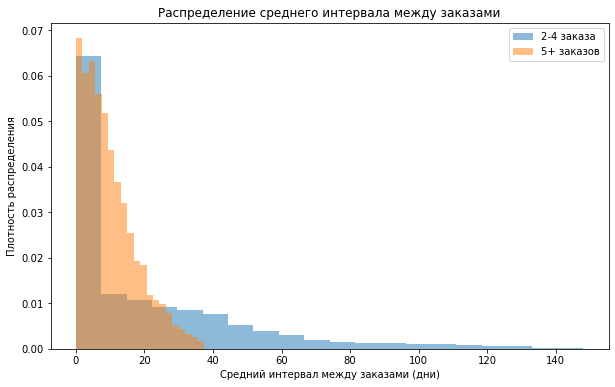

In [61]:
#визуализация 
bins = 20
alpha = 0.5

plt.figure(figsize=(10,6))
plt.hist(group_2_4['avg_days_between_orders'], bins=bins, alpha=alpha, density=True, label='2-4 заказа')
plt.hist(group_5['avg_days_between_orders'], bins=bins, alpha=alpha, density=True, label='5+ заказов')
plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность распределения')
plt.title('Распределение среднего интервала между заказами')
plt.legend()
plt.show()

Средний интервал между заказами существенно влияет на удержание клиентов. Пользователи, совершающие 5 и более заказов, имеют значительно меньший интервал между покупками по сравнению с пользователями, совершившими 2–4 заказа (9.9 дня против 21.3 дня). Это свидетельствует о том, что более высокая частота покупок связана с более высоким уровнем удержания и вовлечённости пользователей.

### Корреляционный анализ количества покупок и признаков пользователя

#### Корреляционный анализ

In [62]:
interval_cols = [
    'avg_revenue',
    'avg_tickets',
    'avg_days_between_orders',
    'lifetime_days',
    'total_orders']

phik_corr = user_profile_work.phik_matrix(interval_cols=interval_cols)

In [63]:
def segment_orders(x):
    if x == 1:
        return '1_order'
    elif 2 <= x <= 4:
        return '2_4_orders'
    else:
        return '5_plus'

user_profile_work['orders_segment'] = user_profile_work['total_orders'].apply(segment_orders)

In [64]:
phik_corr_segment = user_profile_work.phik_matrix(interval_cols=interval_cols)

phik_corr_segment['orders_segment'].sort_values(ascending=False)

is_two                     1.000000
is_five                    1.000000
orders_segment             1.000000
last_order_date            0.607123
first_order_date           0.577723
total_orders               0.488036
avg_days_between_orders    0.389612
avg_tickets                0.383043
avg_revenue                0.325259
region_name                0.123499
service_name               0.079372
event_type_main            0.038181
first_order_weekday        0.033205
device_type_canonical      0.019263
Name: orders_segment, dtype: float64

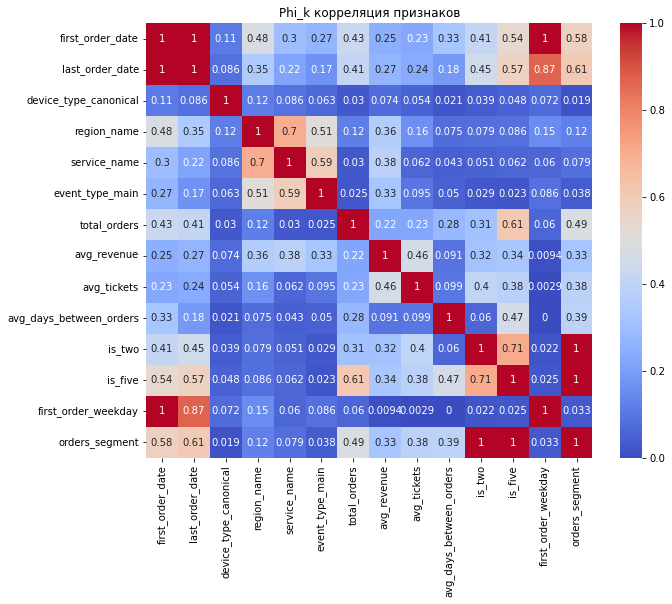

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(phik_corr_segment, annot=True, cmap='coolwarm')
plt.title('Phi_k корреляция признаков')
plt.show()

Наиболее связаны с количеством заказов следующие признаки:
- Дата последнего заказа (last_order_date) — самая высокая связь (phi_k ≈ 0.61).
- Дата первого заказа (first_order_date) — также сильная связь (phi_k ≈ 0.58).

Это означает, что количество заказов в первую очередь связано с длительностью и активностью пользователя в сервисе.

В рамках исследовательского анализа я изучил, какие характеристики первого заказа и поведения пользователей связаны с вероятностью их возвращения на платформу.

1. Признаки первого заказа
- Пользователи распределены по сегментам неравномерно: можно выделить «точки входа» — сегменты, через которые приходит наибольшее число клиентов (по типу мероприятия, устройству и региону).
- При этом вероятность повторной покупки различается между сегментами. Наиболее устойчивую связь с возвратами показывают поведенческие и временные характеристики, тогда как категориальные признаки (например, устройство или регион) оказывают более слабое влияние.
- Проверка продуктовых гипотез показала, что различия между сегментами действительно есть, однако их нужно интерпретировать с учётом размера сегмента: в небольших группах доли могут быть нестабильными.

2. Выручка и состав заказа
- Анализ распределения средней выручки показал различия между пользователями с одним заказом и вернувшимися пользователями. В целом пользователи с повторными покупками демонстрируют более устойчивое поведение и чаще совершают заказы с сопоставимыми или более высокими значениями выручки.
- Также было изучено влияние среднего количества билетов в заказе. Пользователи распределены по сегментам неравномерно, при этом в некоторых сегментах наблюдается более высокая доля повторных покупок. Это может говорить о том, что вовлечённость (например, покупка нескольких билетов) связана с большей вероятностью возврата.

3. Временные характеристики
- Временные параметры показали заметную связь с повторными заказами. День недели первой покупки оказывает ограниченное влияние на возврат, тогда как лайфтайм и средний интервал между заказами связаны с удержанием пользователей заметно сильнее.
- Пользователи с меньшим средним интервалом между заказами чаще переходят в группу с большим числом покупок.
4. Корреляционный анализ
- Корреляционный анализ с использованием коэффициента phi_k показал, что наиболее сильная связь с количеством заказов наблюдается у временных характеристик (дата первого и последнего заказа), а также у поведенческих показателей (средний интервал между заказами, средняя выручка, среднее количество билетов).
- Категориальные признаки (регион, устройство, тип мероприятия) имеют слабую связь с числом заказов.

Количество повторных заказов в большей степени связано с поведением пользователя и длительностью его взаимодействия с сервисом, чем с характеристиками первого заказа или демографическими признаками.

[← Вернуться к содержанию](#содержание)

## Общие выводы и рекомендации

В ходе проекта были проанализированы данные о заказах пользователей сервиса по продаже билетов. В выборку вошли пользователи, совершившие хотя бы один заказ за рассматриваемый период.

На этапе подготовки данных были удалены дубликаты, обработаны пропуски и выбросы по выручке и количеству билетов. Были приведены к единому формату даты, рассчитаны дополнительные признаки: количество заказов на пользователя, средний чек, общее число билетов, интервалы между покупками, а также характеристики первого заказа.

__Основные результаты__

Большинство пользователей совершают только один заказ. Повторных клиентов значительно меньше, но именно они формируют основную часть выручки.

Анализ показал, что с вероятностью повторной покупки связаны:

- более высокая выручка первого заказа;

- большее количество билетов в первом заказе;

- короткий интервал между первой и второй покупкой.

Также наблюдается связь между средним чеком пользователя и числом заказов — клиенты с более высоким средним чеком чаще возвращаются.

Временные характеристики тоже оказывают влияние: пользователи, которые совершают повторную покупку в короткий срок после первой, чаще становятся постоянными клиентами.

__Вывод__

Главная проблема — низкая доля повторных покупателей. При этом уже по характеристикам первого заказа можно определить пользователей с более высокой вероятностью возврата.

__Рекомендации__

1. Сделать акцент на стимулировании второго заказа (например, персональные предложения или скидка после первой покупки).

2. Отдельно работать с пользователями с высоким первым чеком — они потенциально наиболее ценные.

3. Запустить триггерные коммуникации в первые дни после покупки, чтобы сократить интервал до второго заказа.

4. Использовать сегментацию пользователей для более точных маркетинговых предложений.

[← Вернуться к содержанию](#содержание)